## <span style="color:#50C878; font-weight:bold;">Load in Data</span>

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import joblib
from collections import defaultdict
from scipy import stats
from scipy.special import inv_boxcox


# Load the dataset
data = pd.read_csv('../Car_Kh24.csv')

df = pd.DataFrame(data)

# df.info()
# data.isnull().sum()
# df.nunique()
# df.columns

## <span style="color:#50C878; font-weight:bold;">Data Preprocessing</span>

### <span style="color:#50C878; font-weight:bold;">Remove NULL Row</span>


In [22]:
feature_has_missing_values = [
    feature for feature in df.columns if df[feature].isnull().any()
]
df = df.dropna(subset=feature_has_missing_values, how="any")
df.isnull().sum()

Ad ID           0
Category        0
Locations       0
Car Makes       0
Car Model       0
Year            0
Tax Type        0
Condition       0
Body Type       0
Fuel            0
Transmission    0
Color           0
Link            0
Title           0
Price           0
Year Used       0
dtype: int64

### <span style="color:#50C878; font-weight:bold;">Remove Duplicate Data</span>


In [23]:
# find duplicates
duplicates = df[df.duplicated()]

# count duplicates
print(f"Number of duplicate rows: {len(duplicates)}")

#drop duplicates
df = df.drop_duplicates()

Number of duplicate rows: 3


### <span style="color:#50C878; font-weight:bold;">Remove Unknown Data</span>


In [24]:
def check_column_value(df, value):
    """
    Checks if each column in a pandas DataFrame contains a specific value and prints the column names that contain the value.
    
    Parameters:
        df (pandas DataFrame): The DataFrame to check.
        value (any type): The value to look for in each column.
    """
    values = value if isinstance(value, list) else [value]
    matching_columns = df.apply(lambda col: col.isin(values).any())
    matching_columns = matching_columns[matching_columns]

    count = defaultdict(list)
    index = set()

    for val in values:
        for col in matching_columns.index:
            count[col].append(df[df[col] == val].shape[0])
            index.update(df[df[col] == val].index)

    print(f"\033[94mColumns that contain {values}:\n")
    print(pd.Series(count))

    return index

In [25]:
index = check_column_value(df, ['Other', 'Other - ផ្សេងៗ'])
df = df.drop(index, axis='rows')

Columns that contain ['Other', 'Other - ផ្សេងៗ']:

Car Model     [0, 53]
Body Type    [920, 0]
Color        [274, 0]
dtype: object


### <span style="color:#50C878; font-weight:bold;">Drop Unused Columns</span>

In [26]:
df.columns = df.columns.str.strip()

# columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Fuel', 'Transmission', 'Color', 'Link', 'Title', 'Year Used']
columns_to_drop = ['Ad ID', 'Category', 'Locations', 'Link', 'Title']

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.columns

Index(['Car Makes', 'Car Model', 'Year', 'Tax Type', 'Condition', 'Body Type',
       'Fuel', 'Transmission', 'Color', 'Price', 'Year Used'],
      dtype='object')

### <span style="color:#50C878; font-weight:bold;">Convert Price from String to Float</span>

In [27]:
df['Price'] = df['Price'].apply(lambda x: x.split('$')[1].replace(',', '')).astype(float)
df['Price'].dtype

dtype('float64')

### <span style="color:#50C878; font-weight:bold;">Feature Engineering</span>

In [28]:
# Add 'Car Age' feature
df['Car Age'] = 2025 - df['Year']

### <span style="color:#50C878; font-weight:bold;">Handle Skewed Data</span>

C:\Users\Choeng Kimlay\AppData\Local\Temp\ipykernel_31324\1392703603.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )


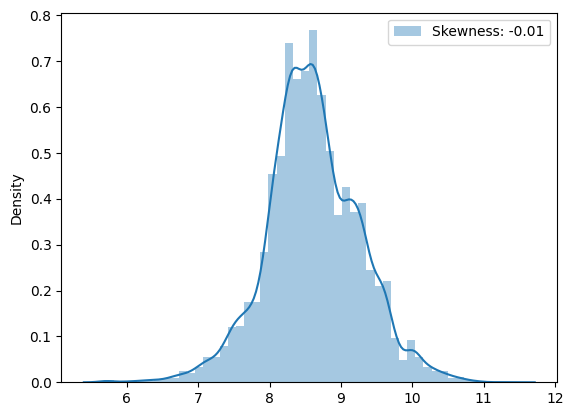

In [29]:
def boxcox(new_df, col):

    # Box-Cox transformation
    transformed_data, lambda_param = stats.boxcox(new_df[col])

    Boxcox = pd.Series(transformed_data)
    
    t=sns.distplot(Boxcox,label="Skewness: %.2f"%(Boxcox.skew()) )
    t.legend()
    return Boxcox, lambda_param

price_boxcox, price_lambda = boxcox(df, 'Price')

In [30]:
df_boxcox = df.copy()
df_boxcox['Price'] = list(price_boxcox)
df_boxcox.shape, df.shape

((11859, 12), (11859, 12))

### <span style="color:#50C878; font-weight:bold;">Detect Outlier</span>

In [31]:
# func to Inter-quartile Range Method
def out_iqr(df , column):
    global lower,upper
    q25, q75 = np.quantile(df[column], 0.25), np.quantile(df[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [32]:
def visualize_outlier(df, col):
    out_iqr(df, col)
    plt.figure(figsize = (10,6))
    sns.distplot(df[col], kde=False)
    plt.axvspan(xmin = lower,xmax= df.Price.min(),alpha=0.2, color='red')
    plt.axvspan(xmin = upper,xmax= df.Price.max(),alpha=0.2, color='red')
    plt.show()

In [33]:
# visualize_outlier(df_boxcox, 'Price')

In [34]:
# visualize_outlier(df, 'Price')

### <span style="color:#50C878; font-weight:bold;">Remove Outlier</span>

In [35]:
def outlier_detection(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    upper_end = Q3 + 1.5 * IQR
    lower_end = Q1 - 1.5 * IQR
    outlier = df[(df > upper_end) | (df < lower_end)]
    return outlier

In [36]:
# # Define price threshold (optional, based on your data)
# price_lower_threshold = df['Price'].quantile(0.25)
# price_upper_threshold = df['Price'].quantile(0.75)

# # Filter out rows where price is out of the defined range
# df = df[(df['Price'] > price_lower_threshold) & (df['Price'] < price_upper_threshold)]

outlier_index = list(outlier_detection(df_boxcox['Price']).index)
df = df_boxcox.drop(outlier_index, axis= 'rows')

### <span style="color:#50C878; font-weight:bold;">Encoding</span>

In [37]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features

# # Identify categorical features
# categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# # Handle high-cardinality feature (e.g., 'Car Model') separately
# high_cardinality_feature = 'Car Model'
# if high_cardinality_feature in categorical_features:
#     # Frequency Encoding for high-cardinality feature
#     freq_map = df[high_cardinality_feature].value_counts().to_dict()
#     df[high_cardinality_feature] = df[high_cardinality_feature].map(freq_map)
    
#     # Remove 'Car Model' from the list of features to one-hot encode
#     categorical_features.remove(high_cardinality_feature)

# Apply One-Hot Encoding to remaining categorical features
df = pd.get_dummies(df, columns=categorical_features)

## <span style="color:#50C878; font-weight:bold;">Model</span>

### <span style="color:#50C878; font-weight:bold;">Train the Elastic Net Regression Model</span>

In [38]:
X = df.drop(columns=['Price'])
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
xgb_model = XGBRegressor(n_estimators=100, random_state=2)
xgb_model.fit(X_train_scaled, y_train)

# Predict the values using the trained model
y_pred = xgb_model.predict(X_test_scaled)

# Calculate the evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")

# Save the model as 'XGB-Model-1 (OH).pkl'
joblib.dump(xgb_model, 'XGB-Model-1 (OH).pkl')
print("Model saved as 'XGB-Model-1 (OH).pkl'")

# Load the model from the saved file
loaded_model = joblib.load('XGB-Model-1 (OH).pkl')

# Predict using the loaded model
y_pred_loaded = loaded_model.predict(X_test_scaled)

# Recalculate the evaluation metrics
mse_best = mean_squared_error(y_test, y_pred_loaded)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_loaded)

print(f"Model MSE: {mse_best}")
print(f"Model RMSE: {rmse_best}")
print(f"Model R-squared: {r2_best}")
print("XGB-Model-1 (OH).pkl")

# Apply the inverse Box-Cox transformation to revert the predicted values to their original scale
y_pred_original = inv_boxcox(y_pred_loaded, price_lambda)  # price_lambda is the lambda used during transformation

# Apply the inverse Box-Cox to the actual values (test set) as well
y_test_original = inv_boxcox(y_test, price_lambda)

# Create a DataFrame to compare true and predicted values (after reverting the transformation)
results_df = pd.DataFrame({
    'True Price': y_test_original,
    'Predicted Price': y_pred_original,
    'Residuals': y_test_original - y_pred_original
})

# Format the results in dollars (in the thousands, as it's for car prices)
results_df['True Price'] = results_df['True Price'].apply(lambda x: f"${x / 1000:,.2f}K")
results_df['Predicted Price'] = results_df['Predicted Price'].apply(lambda x: f"${x / 1000:,.2f}K")
results_df['Residuals'] = results_df['Residuals'].apply(lambda x: f"${x / 1000:,.2f}K")

# Show the results
print(results_df.head(10))

Mean Squared Error: 0.029320603748998926
Root Mean Squared Error: 0.17123260130301976
Mean Absolute Error: 0.10631891157578738
R-squared: 0.9174178326648109
Model saved as 'XGB-Model-1 (OH).pkl'
Model MSE: 0.029320603748998926
Model RMSE: 0.17123260130301976
Model R-squared: 0.9174178326648109
XGB-Model-1 (OH).pkl
      True Price Predicted Price Residuals
13047    $16.15K         $16.70K   $-0.55K
9585      $5.80K          $5.77K    $0.03K
5711     $28.90K         $31.01K   $-2.11K
5067     $40.50K         $38.48K    $2.02K
15804    $46.90K         $50.85K   $-3.95K
1107      $8.50K         $10.96K   $-2.46K
7549     $49.50K         $47.08K    $2.42K
1254     $16.90K         $13.42K    $3.48K
14245    $79.90K         $71.28K    $8.62K
11845    $17.00K         $23.48K   $-6.48K


### <span style="color:#50C878; font-weight:bold;">Model Tuning</span>

### <span style="color:#50C878; font-weight:bold;">Cross-Validation</span>